# Interrater Playground

Visualize exported interrater masks overlaid on the reviewed images.

In [24]:
import json
import random
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

TOOLS_ROOT = Path('/home/ultrai/UltrAi/knee_us_segmentation/tools_image-review')
IMAGEJ_DATA_ROOT = TOOLS_ROOT / 'ImageJ - Knee US Cartilage Segmentation' / 'data'
MASTER_LIST_PATH = TOOLS_ROOT / 'master_list.json'
MANIFEST_PATH = Path('data/interrater/interrater_manifest.csv')
INTER_RATER_ROOT = Path('data/interrater')

session = 'Session 1'
image_ids = []
num_samples = 4
random_seed = 42

In [25]:
with open(MASTER_LIST_PATH, 'r') as f:
    master_list = {str(k): Path(v).stem for k, v in json.load(f).items()}

manifest_df = pd.read_csv(MANIFEST_PATH)
manifest_df['anonymized_id'] = manifest_df['anonymized_id'].astype(str)
manifest_df['original_image_id'] = manifest_df['original_image_id'].astype(str)

display(manifest_df.head())
print(f'Manifest rows: {len(manifest_df)}')
manifest_df['label_style_image_id'] = manifest_df['label_style_image_id'].astype(str)
manifest_df['expert_mask_path'] = manifest_df['expert_mask_path'].astype(str)

display(manifest_df.head())
print(f'Manifest rows: {len(manifest_df)}')
print(f'Unique label-style image ids: {manifest_df["label_style_image_id"].nunique()}')

,annotator,session,anonymized_id,original_image_id,label_style_image_id,is_duplicate_image,duplicate_index,export_name,export_path,expert_mask_path,crop_left,crop_right
0,Will,Session 1,0,Tufts_6m_Jamil_s004_v3_l_120_3,Tufts_6m_Jamil___s004_v3_l_120_3,False,0,Tufts_6m_Jamil___s004_v3_l_120_3.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,123,596
1,Ibrahim,Session 1,0,Tufts_6m_Jamil_s004_v3_l_120_3,Tufts_6m_Jamil___s004_v3_l_120_3,False,0,Tufts_6m_Jamil___s004_v3_l_120_3.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Ibra...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,123,596
2,Will,Session 1,1,ACLMRI_Michel_MRI_S005_L_CAR_2,ACLMRI_Michel___MRI_S005_L_CAR_2,True,0,ACLMRI_Michel___MRI_S005_L_CAR_2.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,344,1108
3,Ibrahim,Session 1,1,ACLMRI_Michel_MRI_S005_L_CAR_2,ACLMRI_Michel___MRI_S005_L_CAR_2,True,0,ACLMRI_Michel___MRI_S005_L_CAR_2.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Ibra...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,344,1108
4,Will,Session 1,2,CaseControl_ACL_ACL08_CC21_r1_non-inj_central_...,CaseControl_ACL___ACL08_CC21_r1_non-inj_centra...,False,0,CaseControl_ACL___ACL08_CC21_r1_non-inj_centra...,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,107,586


Manifest rows: 146


,annotator,session,anonymized_id,original_image_id,label_style_image_id,is_duplicate_image,duplicate_index,export_name,export_path,expert_mask_path,crop_left,crop_right
0,Will,Session 1,0,Tufts_6m_Jamil_s004_v3_l_120_3,Tufts_6m_Jamil___s004_v3_l_120_3,False,0,Tufts_6m_Jamil___s004_v3_l_120_3.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,123,596
1,Ibrahim,Session 1,0,Tufts_6m_Jamil_s004_v3_l_120_3,Tufts_6m_Jamil___s004_v3_l_120_3,False,0,Tufts_6m_Jamil___s004_v3_l_120_3.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Ibra...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,123,596
2,Will,Session 1,1,ACLMRI_Michel_MRI_S005_L_CAR_2,ACLMRI_Michel___MRI_S005_L_CAR_2,True,0,ACLMRI_Michel___MRI_S005_L_CAR_2.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,344,1108
3,Ibrahim,Session 1,1,ACLMRI_Michel_MRI_S005_L_CAR_2,ACLMRI_Michel___MRI_S005_L_CAR_2,True,0,ACLMRI_Michel___MRI_S005_L_CAR_2.png,/home/ultrai/UltrAi/UNeXt/data/interrater/Ibra...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,344,1108
4,Will,Session 1,2,CaseControl_ACL_ACL08_CC21_r1_non-inj_central_...,CaseControl_ACL___ACL08_CC21_r1_non-inj_centra...,False,0,CaseControl_ACL___ACL08_CC21_r1_non-inj_centra...,/home/ultrai/UltrAi/UNeXt/data/interrater/Will...,/home/ultrai/UltrAi/knee_us_segmentation/data/...,107,586


Manifest rows: 146
Unique label-style image ids: 73


In [35]:
def get_review_image_path(session_name, anonymized_id):
    return IMAGEJ_DATA_ROOT / 'images' / session_name / f'{anonymized_id}.tif'


def get_mask_path(annotator, export_name):
    return INTER_RATER_ROOT / annotator / export_name


def get_original_label_path(row):
    return Path(row['expert_mask_path'])


def select_samples(manifest_df, session_name, image_ids=None, num_samples=4, random_seed=42):
    session_df = manifest_df[(manifest_df['session'] == session_name) & (manifest_df['annotator'] == 'Will')].copy()
    session_df = session_df.sort_values(['label_style_image_id', 'duplicate_index', 'anonymized_id'])

    if image_ids:
        selected = session_df[session_df['label_style_image_id'].isin(image_ids)].copy()
    else:
        random.seed(random_seed)
        unique_ids = session_df['label_style_image_id'].drop_duplicates().tolist()
        if len(unique_ids) > num_samples:
            unique_ids = random.sample(unique_ids, num_samples)
        selected = session_df[session_df['label_style_image_id'].isin(unique_ids)].copy()

    return selected.drop_duplicates('label_style_image_id').sort_values('label_style_image_id')


def plot_samples(sample_df):
    if len(sample_df) == 0:
        print('No samples found for the current selection.')
        return

    fig, axes = plt.subplots(len(sample_df), 5, figsize=(17, 2 * len(sample_df)))
    if len(sample_df) == 1:
        axes = [axes]

    for row_axes, (_, row) in zip(axes, sample_df.iterrows()):
        review_image = Image.open(get_review_image_path(row['session'], row['anonymized_id'])).convert('L')
        review_image = review_image.copy()
        img = np.array(review_image)

        original_mask = np.array(Image.open(get_original_label_path(row)).convert('L')) > 0
        will_mask = np.array(Image.open(get_mask_path('Will', row['export_name'])).convert('L')) > 0
        ibrahim_mask = np.array(Image.open(get_mask_path('Ibrahim', row['export_name'])).convert('L')) > 0

        titles = ['image', 'image + original', 'image + Will', 'image + Ibrahim', 'image + all']
        for ax, title in zip(row_axes, titles):
            ax.imshow(img, cmap='gray')
            ax.set_title(title)
            ax.axis('off')

        row_axes[1].contour(original_mask, colors='cyan', linewidths=0.7)
        row_axes[2].contour(will_mask, colors='yellow', linewidths=0.7)
        row_axes[3].contour(ibrahim_mask, colors='red', linewidths=0.7)
        row_axes[4].contour(original_mask, colors='cyan', linewidths=0.7)
        row_axes[4].contour(will_mask, colors='yellow', linewidths=0.7)
        row_axes[4].contour(ibrahim_mask, colors='red', linewidths=0.7)
        # row_axes[0].text(
        #     0.01,
        #     0.01,
        #     f"{row['label_style_image_id']}\n{row['session']} / {row['anonymized_id']}",
        #     transform=row_axes[0].transAxes,
        #     fontsize=9,
        #     color='white',
        #     ha='left',
        #     va='bottom',
        #     bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.2')
        # )

    plt.tight_layout()
    plt.show()

,session,anonymized_id,label_style_image_id,duplicate_index
2,Session 1,1,ACLMRI_Michel___MRI_S005_L_CAR_2,0
10,Session 1,5,CaseControl_Control___s01_r1_dom_central_pre_c...,0
12,Session 1,7,Nike_Arjun_clarius_auto___Nike_s907_L_CAR_3,0
38,Session 1,22,Nike_Arjun_clarius_auto___Nike_s909_L_CAR_5,0


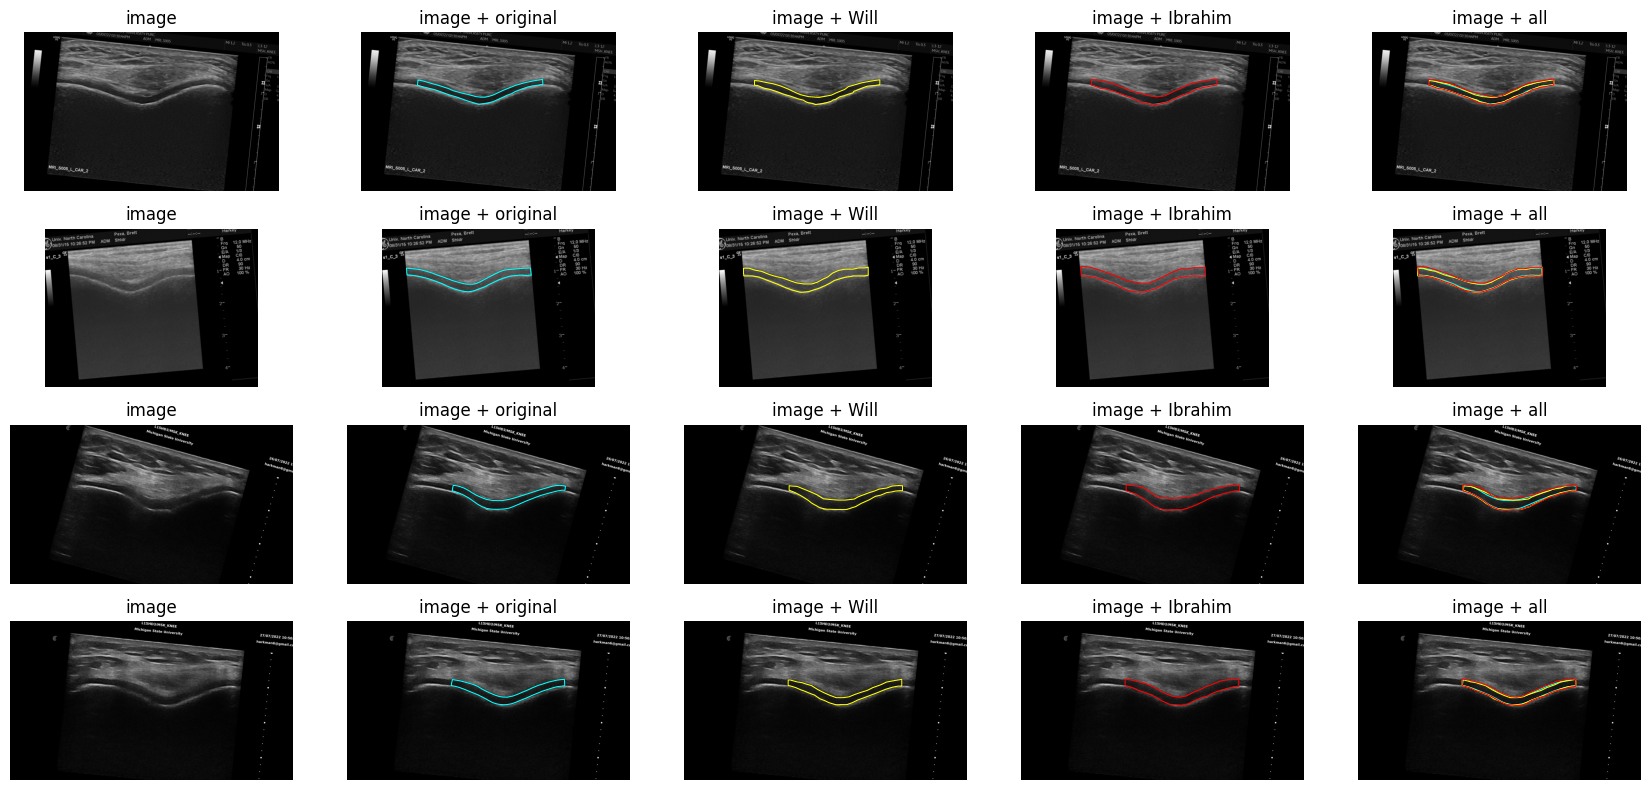

In [36]:
samples_df = select_samples(
    manifest_df,
    session_name=session,
    image_ids=image_ids,
    num_samples=num_samples,
    random_seed=random_seed,
)
display(samples_df[['session', 'anonymized_id', 'label_style_image_id', 'duplicate_index']])
plot_samples(samples_df)